<p><font size="6" color='grey'> <b>

Generative KI. Verstehen. Anwenden. Gestalten.
</b></font> </br></p>

<p><font size="5" color='grey'> <b>
Multimodales RAG
</b></font> </br></p>


---

In [1]:
#@title 🔧 Umgebung einrichten{ display-mode: "form" }
!uv pip install --system -q git+https://github.com/ralf-42/GenAI.git#subdirectory=04_modul
from genai_lib.utilities import (
    check_environment,
    get_ipinfo,
    setup_api_keys,
    mprint,
    install_packages,
    mermaid,
    get_model_profile,
    extract_thinking,
    load_prompt
)
setup_api_keys(['OPENAI_API_KEY', 'HF_TOKEN'], create_globals=False)
print()
check_environment()
print()
get_ipinfo()

✓ OPENAI_API_KEY erfolgreich gesetzt
✓ HF_TOKEN erfolgreich gesetzt

Python Version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]

Installierte LangChain- und LangGraph-Bibliotheken:
langchain                                1.2.8
langchain-chroma                         1.1.0
langchain-classic                        1.0.1
langchain-community                      0.4.1
langchain-core                           1.2.9
langchain-ollama                         1.0.1
langchain-openai                         1.1.8
langchain-text-splitters                 1.1.0
langgraph                                1.0.7
langgraph-checkpoint                     4.0.0
langgraph-prebuilt                       1.0.7
langgraph-sdk                            0.3.3

IP-Adresse: 34.48.113.209
Hostname: 209.113.48.34.bc.googleusercontent.com
Stadt: Washington
Region: District of Columbia
Land: US
Koordinaten: 38.8951,-77.0364
Provider: AS396982 Google LLC
Postleitzahl: 20004
Zeitzone: America/New_York


In [2]:
#@title 🛠️ Installationen { display-mode: "form" }
install_packages([
    ('markitdown[all]', 'markitdown'),
])

🔄 Installiere markitdown[all]...
✅ markitdown[all] erfolgreich installiert und importiert


In [3]:
#@title 📂 Dokumente, Bilder { display-mode: "form" }
!rm -rf files
!mkdir files

# --- Texte
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/01_text/biografien_1.txt -o files/biografien_1.txt
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/01_text/biografien_2.md -o files/biografien_2.md
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/01_text/biografien_3.pdf -o files/biografien_3.pdf
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/01_text/biografien_4.docx -o files/biografien_4.docx
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/01_text/roboter.txt -o files/roboter.txt

# --- Bilder
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/02_bild/retro_robot.jpg -o files/retro_robot.jpg
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/02_bild/hedra_cyborg.png -o files/hedra_cyborg.png
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/02_bild/apfel.png -o files/apfel.png
!curl -L https://raw.githubusercontent.com/ralf-42/GenAI/main/02_daten/02_bild/zwei_roboter.png -o zwei_roboter.png

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5324  100  5324    0     0  29349      0 --:--:-- --:--:-- --:--:-- 29414
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7868  100  7868    0     0  59658      0 --:--:-- --:--:-- --:--:-- 60061
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 68184  100 68184    0     0   324k      0 --:--:-- --:--:-- --:--:--  323k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 18743  100 18743    0     0   124k      0 --:--:-- --:--:-- --:--:--  125k
  % Total    % Received % Xferd  Average Speed   Tim

<p><font color='black' size="5">
⏸️ 5-Minuten-Check:
</font></p>

**Ziel:** Prüfen, ob du das vorherige Kapitel verstanden hast – nicht, ob es gerade läuft.

**Aufgabe** (5 Minuten, ohne Vorlage):

Rekonstruiere die zentrale Idee oder Code-Struktur des letzten Abschnitts selbstständig
(kein Copy & Paste, kein Nachschlagen).

Wähle eine der folgenden Optionen:

+ Erkläre in 1–2 Sätzen, was hier konzeptionell passiert.

+ Verändere eine Kleinigkeit (z. B. Prompt, Parameter, Reihenfolge) und beschreibe die Auswirkung.

+ Markiere eine Stelle, die du nicht sicher erklären kannst, und formuliere eine konkrete Frage dazu.

**Hinweis:**
Nicht alles muss „fertig“ oder „korrekt“ sein. Entscheidend ist, wo dein Verständnis gerade endet

# 1 | RAG-Prozess
---

In dem entwickelten **multimodalen Retrieval-Augmented-Generation (RAG)**-System werden sowohl Text- als auch Bilddaten verarbeitet.
Für die **Bildverarbeitung** kommt ein zweistufiger Ansatz zum Einsatz:

1. **Image-Embedding:**
   Das Bild wird in einen hochdimensionalen Vektorraum eingebettet, um visuelle Merkmale wie Formen, Farben und Strukturen numerisch zu repräsentieren.

2. **Textbeschreibung und Text-Embedding:**
   Zusätzlich wird mit *gpt-4o-mini* eine sprachliche Beschreibung des Bildes erzeugt. Diese Beschreibung wird anschließend in ein Text-Embedding überführt, um semantische Informationen textbasiert nutzbar zu machen.

---

**Vorteile des Ansatzes:**

* **Erweiterte semantische Repräsentation:**
  Durch die Kombination von visuellen und sprachlichen Embeddings werden sowohl konkrete als auch konzeptuelle Eigenschaften eines Bildes abgebildet.

* **Verbesserte Retrieval-Qualität:**
  Textbasierte Suchanfragen können nicht nur über visuelle Ähnlichkeiten, sondern auch über die semantisch beschriebene Bedeutung der Bilder beantwortet werden.

* **Höhere Interpretierbarkeit:**
  Die generierte Bildbeschreibung ermöglicht eine transparente Nachvollziehbarkeit der zugrunde liegenden Repräsentationen und unterstützt bei der Evaluierung der Ergebnisse.

* **Gute Erweiterbarkeit:**
  Das Verfahren ist modular aufgebaut und lässt sich leicht um weitere Modalitäten wie Audio oder Video ergänzen.


<p><font color='black' size="5">
RAG-Prozess für Texte
</font></p>

<img src="https://raw.githubusercontent.com/ralf-42/GenAI/main/07_image/rag_process.png" width="600" alt="Avatar">

<p><font color='black' size="5">
RAG-Prozess für Bilder
</font></p>

<img src="https://raw.githubusercontent.com/ralf-42/GenAI/main/07_image/rag_process_03.png" width="600" alt="Avatar">

# 2 | Modul `multimodal_rag`
---

Python-Modul für ein **funktionales multimodales RAG-System**, das Text- und Bilddokumente in einer einheitlichen Vektordatenbank verwaltet und durchsucht.

**Modalitätsrichtungen**

| Eingabe (Query) | Ausgabe (Antwort) | Beispiel / Beschreibung | Status |
|-----------------|-------------------|-------------------------|--------|
| **Text → Text** | Textbasierte Frage führt zu Textantwort | Klassisches RAG-System (z.B. Chatbot, Q&A) | ✅ |
| **Text → Bild** | Textanfrage findet relevante Bilder | "Zeige mir Roboter-Bilder" | ✅ |
| **Bild → Text** | Bildanalyse oder Captioning | "Was ist auf diesem Foto zu sehen?" | ✅ |
| **Bild → Bild** | Bildretrieval oder visuelle Transformation | "Finde ähnliche Bilder" | ✅ |
| **Bild → Text/Bild** | Erweiterte multimodale Suche mit Bild | "Alle Infos zu diesem Bild" (CLIP + Semantik + Cross-Modal) | ✅ |
| **Text + Bild → Text** | Kombination zur Textgenerierung | "Welche Informationen enthält dieses Diagramm?" | ❌ |
| **Text + Bild → Bild** | Bedingte Bildgenerierung | "Mach aus diesem Bild eine Winterversion" | ❌ |

**Hauptvorteile**

1. **Funktionale Architektur**: Klare Trennung von Konfiguration, Komponenten und Funktionen
2. **Einheitliche Datenbank**: ChromaDB mit separaten Collections für Text und Bilder
3. **Hybride Suche**: Text-Embeddings (OpenAI) + Bild-Embeddings (CLIP)
4. **Flexible Konfiguration**: Alle Parameter über RAGConfig anpassbar
5. **Bildbeschreibung**: Zu jedem Bild wird zusätzlich eine Bildbeschreibung erstellt.

<p><font color='black' size="5">
Aufbau
</font></p>

**RAGConfig**
- Zentrale Konfigurationsklasse
- Anpassbare Parameter (chunk_size, models, thresholds)

**RAGComponents**
- Container für alle System-Komponenten
- Text-Embeddings, CLIP-Model, LLMs, Collections

**Hauptfunktionen**
- Datensammlung
    - `init_rag_system()`: System-Initialisierung
    - `process_directory()`: Bulk-Import von Dateien
    - `add_text_document()`: Einzelnes Dokument hinzufügen
    - `add_image_with_description()`: Bild mit Auto-Beschreibung
- Abruf & Erweiterung
    - `search_texts()`: Text-Suche inkl. Bildbeschreibungen
    - `search_images()`: CLIP-basierte Bildsuche
    - `search_similar_images()`: Bild→Bild Ähnlichkeitssuche
    - `search_text_by_image()`: Bild→Text Suche
    - `multimodal_search()`: Erweiterte multimodale Suche (Text-Query)
    - `multimodal_search_by_image()`: Erweiterte multimodale Suche (Bild-Query)

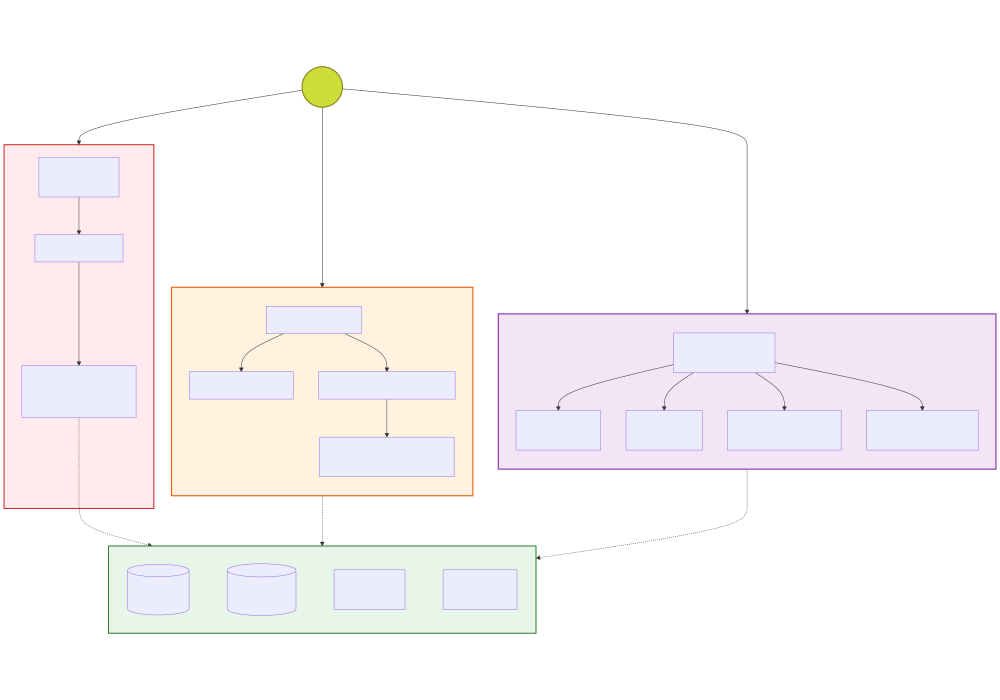

In [4]:
#@markdown   <p><font size="4" color='green'> 🧜‍♀️ Prozess-Diagramm</font> </br></p>


diagram = """
flowchart TB
    User(("Benutzer"))

    subgraph Init["Systeminitialisierung"]
        direction TB
        RAGConfig["RAGConfig<br/>Konfiguration"]
        init_rag["init_rag_system"]
        RAGComponents["RAGComponents<br/>Text-Embeddings, CLIP,<br/>LLMs, Collections"]

        RAGConfig --> init_rag
        init_rag --> RAGComponents
    end

    subgraph Generate["Datensammlung"]
        direction TB
        process_dir["process_directory"]
        add_text["add_text_document"]
        add_image["add_image_with_description"]
        generate_desc["generate_image_description<br/>Vision LLM"]

        process_dir --> add_text
        process_dir --> add_image
        add_image --> generate_desc
    end

    subgraph Search["Suchfunktionen"]
        direction TB
        multimodal["multimodal_search<br/>Kombinierte Suche"]
        search_text_by_img["search_text_by_image<br/>Bild → Text"]
        search_images["search_images<br/>Text → Bild"]
        search_texts["search_texts<br/>Text → Text"]
        search_similar["search_similar_images<br/>Bild → Bild"]

        multimodal --> search_images
        multimodal --> search_texts
        multimodal --> search_similar
        multimodal --> search_text_by_img
    end

    subgraph DB["Datenbanken & Modelle"]
        direction LR
        text_coll[("Text Collection<br/>ChromaDB")]
        image_coll[("Image Collection<br/>ChromaDB")]
        clip["CLIP Model<br/>ViT-B-32"]
        llm["LLM<br/>gpt-4o-mini"]

        text_coll ~~~ image_coll ~~~ clip ~~~ llm
    end

    %% Benutzer-Verbindungen
    User -->|"#1 Init"| Init
    User -->|"#2 Generate"| Generate
    User -->|"#3 Search"| Search

    %% Init zu DB
    RAGComponents -.->|"initialisiert"| DB

    %% Generate zu DB
    Generate -.->|"speichert"| DB

    %% Search zu DB
    Search -.->|"abfragt"| DB

    %% Styling
    style Init fill:#ffebee,stroke:#c62828,stroke-width:2px
    style Generate fill:#fff3e0,stroke:#e65100,stroke-width:2px
    style Search fill:#f3e5f5,stroke:#7b1fa2,stroke-width:2px
    style DB fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
    style User fill:#cddc39,stroke:#827717,stroke-width:2px
"""
mermaid(diagram, 1000, 700)


In [5]:
# Import des Moduls
from genai_lib.multimodal_rag import (
    # Init
    init_rag_system,
    get_system_status,

    # Generate
    process_directory,
    add_text_document,
    add_image_with_description,

    # Search
    multimodal_search,
    multimodal_search_by_image,
    search_texts,
    search_images,
    search_text_by_image,
    search_similar_images,
)

# 3 | RAG initialisieren
---

In [6]:
# Initialisierung
rag = init_rag_system()

🚀 Initialisiere Enhanced RAG-System in ./multimodal_rag_db
✅ OpenAI Text-Embeddings initialisiert
🖼️ Lade CLIP-Modell...


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ CLIP-Modell geladen
✅ LLMs initialisiert (Text + Vision)
✅ Collections initialisiert



In [7]:
# Konfiguration abfragen
print(rag.config)

# Konfiguration ändern (Beispiel: chunk_size ändern)
# rag.config.chunk_size = 300

RAGConfig(chunk_size=200, chunk_overlap=20, text_min_similarity=0.3, image_threshold=0.8, clip_model='clip-ViT-B-32', text_model='text-embedding-3-small', llm_model='gpt-4o-mini', vision_model='gpt-4o-mini', db_path='./multimodal_rag_db')


# 4 | Datensammlung
---

In [8]:
# Dokumente/Bilder laden & verarbeiten
process_directory(rag, './files', auto_describe_images=True)

📊 Gefunden: 5 Text-Dateien, 3 Bilder

📄 biografien_3.pdf
✅ 68 Chunks von 'biografien_3.pdf' hinzugefügt
📄 biografien_4.docx
✅ 63 Chunks von 'biografien_4.docx' hinzugefügt
📄 roboter.txt
✅ 11 Chunks von 'roboter.txt' hinzugefügt
📄 biografien_1.txt
✅ 32 Chunks von 'biografien_1.txt' hinzugefügt
📄 biografien_2.md
✅ 44 Chunks von 'biografien_2.md' hinzugefügt

🖼️ apfel.png
🖼️ Bild-Embedding erstellt für apfel.png
📝 Bildbeschreibung generiert: Das Bild zeigt einen glänzenden roten Apfel, der auf einer Holzoberfläche platziert ist. Die Farben ...
✅ Bildbeschreibung in Text-Collection gespeichert
✅ Bild 'apfel.png' mit Cross-References hinzugefügt

🖼️ retro_robot.jpg
🖼️ Bild-Embedding erstellt für retro_robot.jpg
📝 Bildbeschreibung generiert: Das Bild zeigt einen freundlichen, silbernen Roboter, der vor einem Gebäude steht, das mit einem Sch...
✅ Bildbeschreibung in Text-Collection gespeichert
✅ Bild 'retro_robot.jpg' mit Cross-References hinzugefügt

🖼️ hedra_cyborg.png
🖼️ Bild-Embedding ers

{'texts': 5, 'images': 3, 'image_descriptions': 3}

# 5 | Suche mit Text
---

<p><font color='black' size="5">
Text → Text
</font></p>

In [9]:
result = search_texts(rag, "Was weisst Du über Cyborgs?")
mprint(result)

### 🤖 LLM-Antwort

Cyborgs sind hybride Wesen, die sowohl biologische als auch technologische Komponenten vereinen. Sie können Menschen sein, die durch mechanische oder elektronische Teile ergänzt wurden, um ihre Fähigkeiten zu erweitern oder zu verbessern. In der Science-Fiction werden Cyborgs oft als fortschrittliche Krieger oder Helden dargestellt, die übermenschliche Kräfte oder Fähigkeiten besitzen. Die ethischen und gesellschaftlichen Implikationen von Cyborgs sind vielfältig, insbesondere in Bezug auf Identität, Verantwortung und die Grenzen zwischen Mensch und Maschine.

### 📚 Verwendete Quellen

   📄 Text-Dokumente (2):
      1. roboter.txt (Ähnlichkeit: 0.444)
      2. roboter.txt (Ähnlichkeit: 0.431)

   🖼️ Bildbeschreibungen (1):
      1. hedra_cyborg.png (Ähnlichkeit: 0.541)


<p><font color='black' size="5">
Text → Bild
</font></p>

In [10]:
result = search_images(rag, "Was weisst Du über Cyborgs?")
mprint(result)

### 🤖 LLM-Antwort

Cyborgs sind hybride Wesen, die sowohl biologische als auch technologische Komponenten vereinen. Sie können Menschen oder Tiere sein, die durch mechanische oder elektronische Teile ergänzt oder verbessert wurden, um ihre Fähigkeiten zu erweitern oder zu verändern. In der Science-Fiction werden Cyborgs oft als futuristische Charaktere dargestellt, die über überlegene Kräfte oder Fähigkeiten verfügen. Sie können in verschiedenen Kontexten auftreten, von militärischen Anwendungen bis hin zu alltäglichen Lebenssituationen, und sind häufig mit Themen wie Identität, Menschlichkeit und Technologie verbunden.

### 🖼️ Gefundene Bilder (via CLIP)

   1. hedra_cyborg.png (Ähnlichkeit: 0.239)
      📝 Das Bild zeigt einen männlichen Charakter in einem futuristischen, rüstungsähnlichen Anzug, der aus dunklem, metallischem Material besteht. Die Farben sind überwiegend in Grautönen gehalten, mit blauen Akzenten, was eine kühle und ernste Stimmung erzeugt. Der Hintergrund ist unscharf, lässt jedoch a...
   2. retro_robot.jpg (Ähnlichkeit: 0.22)
      📝 Das Bild zeigt einen freundlichen, silbernen Roboter, der vor einem Gebäude steht, das mit einem Schild "WELCOME ROBOTS WELCOME" geschmückt ist. Die Farben sind hell und lebhaft, mit einem warmen, einladenden Gefühl, das durch die goldenen und orangefarbenen Töne im Hintergrund verstärkt wird. Die K...


<p><font color='black' size="5">
Text → Text/Bild
</font></p>

In [11]:
result = multimodal_search(rag, "Was weisst Du über Cyborgs?")
mprint(result)

### 🤖 LLM-Antwort

Cyborgs sind hybride Wesen, die sowohl biologische als auch mechanische Komponenten besitzen. Sie kombinieren menschliche oder tierische Eigenschaften mit technologischen Erweiterungen, um ihre Fähigkeiten zu verbessern oder neue Funktionen zu ermöglichen. In der Science-Fiction werden Cyborgs oft als fortschrittliche Krieger oder Helden dargestellt, die durch ihre Technologie übermenschliche Kräfte oder Fähigkeiten erhalten. Ethische und gesellschaftliche Fragen, wie die Identität und Verantwortung von Cyborgs, sind häufige Themen in Geschichten, die sich mit dieser Thematik befassen.

### 📚 Verwendete Quellen (via semantische Textsuche)

   📄 Text-Dokumente (2):
      1. roboter.txt (Ähnlichkeit: 0.444)
      2. roboter.txt (Ähnlichkeit: 0.431)

   🖼️ Bildbeschreibungen (1):
      1. hedra_cyborg.png (Ähnlichkeit: 0.541)

### 🔍 Bilder via CLIP (direkte visuelle Ähnlichkeitssuche)
   1. hedra_cyborg.png (Ähnlichkeit: 0.239)
      📝 Das Bild zeigt einen männlichen Charakter in einem futuristischen, rüstungsähnlichen Anzug, der aus dunklem, metallischem Material besteht. Die Farben sind überwiegend in Grautönen gehalten, mit blauen Akzenten, was eine kühle und ernste Stimmung erzeugt. Der Hintergrund ist unscharf, lässt jedoch a...
   2. retro_robot.jpg (Ähnlichkeit: 0.22)
      📝 Das Bild zeigt einen freundlichen, silbernen Roboter, der vor einem Gebäude steht, das mit einem Schild "WELCOME ROBOTS WELCOME" geschmückt ist. Die Farben sind hell und lebhaft, mit einem warmen, einladenden Gefühl, das durch die goldenen und orangefarbenen Töne im Hintergrund verstärkt wird. Die K...

### 🔗 Bilder via Cross-Modal Retrieval (Text → Bild Verknüpfung)
   1. hedra_cyborg.png
      📝 Das Bild zeigt einen männlichen Charakter in einem futuristischen, rüstungsähnlichen Anzug, der aus dunklem, metallischem Material besteht. Die Farben sind überwiegend in Grautönen gehalten, mit blauen Akzenten, was eine kühle und ernste Stimmung erzeugt. Der Hintergrund ist unscharf, lässt jedoch a...


# 6 | Suche mit Bild
---

<p><font color='black' size="5">
Bild → Bild
</font></p>

In [12]:
result = search_similar_images(rag, "./zwei_roboter.png", k=5)
mprint("## 🖼️ Suche Bild → Bild")
mprint("---")
for img in result:
    mprint(f"{img['filename']}: Ähnlichkeit: {img['similarity']}")

🔍 CLIP-Embedding erstellt für Query-Bild: zwei_roboter.png
✅ 3 ähnliche Bilder gefunden



## 🖼️ Suche Bild → Bild

---

retro_robot.jpg: Ähnlichkeit: 0.829

apfel.png: Ähnlichkeit: 0.677

hedra_cyborg.png: Ähnlichkeit: 0.469

<p><font color='black' size="5">
Bild → Text
</font></p>

In [13]:
result = search_text_by_image(rag, "./zwei_roboter.png", k=5)
mprint(result)

🔍 CLIP-Embedding erstellt für Query-Bild: zwei_roboter.png
✅ 3 ähnliche Bilder gefunden

🔍 Suche nach relevanten Text-Dokumenten basierend auf Bildbeschreibungen...
✅ 3 relevante Text-Dokumente gefunden



### 🤖 LLM-Antwort

Die Analyse der visuell ähnlichen Bilder und relevanten Textdokumente zeigt eine klare Verbindung zu Robotern und deren Integration in die Gesellschaft. 

**Gemeinsamkeiten und wichtige Merkmale:**
1. **Thema der Robotik:** Alle Bilder und Texte thematisieren Roboter, wobei das Bild des freundlichen Roboters in retro_robot.jpg besonders hervortritt. Es vermittelt eine positive Einstellung zur Robotik und deren Akzeptanz in der Gesellschaft.
2. **Futuristische Elemente:** Sowohl das Bild des Roboters als auch das Bild des Cyborgs (hedra_cyborg.png) zeigen futuristische Designs, die auf eine technologische Weiterentwicklung hinweisen. Dies spiegelt sich auch in den Texten wider, die die Evolution von Robotern von industriellen Werkzeugen zu komplexen, autonomen Systemen beschreiben.
3. **Einladende Atmosphäre:** Das Bild des Roboters strahlt eine warme, einladende Stimmung aus, was im Kontrast zu dem ernsteren Ton des Cyborgs steht. Diese unterschiedlichen Darstellungen zeigen die Bandbreite der Robotik, von freundlichen Begleitern bis hin zu kämpferischen Charakteren.

**Relevante Kontextinformationen:**
- Die Texte betonen, dass Roboter nicht nur technische Werkzeuge sind, sondern auch Ausdruck menschlicher Kreativität und Ambition. Sie sind mittlerweile ein fester Bestandteil des Alltags und der industriellen Produktion, was die gesellschaftliche Akzeptanz und Integration von Robotern unterstreicht.
- Die Entwicklung von Robotern hin zu Servicerobotern und autonomen Fahrzeugen wird in den Texten hervorgehoben, was die Vielfalt der Anwendungen und die sich verändernde Wahrnehmung von Robotern verdeutlicht.

Insgesamt zeigen die Informationen, dass Roboter in verschiedenen Kontexten dargestellt werden, von freundlichen Begleitern bis hin zu komplexen, futuristischen Wesen, und dass sie eine zunehmend wichtige Rolle in der modernen Gesellschaft spielen.

### 🔍 Verwendete Quellen (visuell ähnliche Bilder via CLIP)
   1. retro_robot.jpg (Ähnlichkeit: 0.829)
      📝 Das Bild zeigt einen freundlichen, silbernen Roboter, der vor einem Gebäude steht, das mit einem Schild "WELCOME ROBOTS WELCOME" geschmückt ist. Die Farben sind hell und lebhaft, mit einem warmen, einladenden Gefühl, das durch die goldenen und orangefarbenen Töne im Hintergrund verstärkt wird. Die K...
   2. apfel.png (Ähnlichkeit: 0.677)
      📝 Das Bild zeigt einen glänzenden roten Apfel, der auf einer Holzoberfläche platziert ist. Die Farben sind lebhaft, mit einem satten Rot des Apfels und einem sanften, neutralen Hintergrund, der eine warme und einladende Stimmung erzeugt. Die Komposition ist einfach und fokussiert, wobei der Apfel zent...
   3. hedra_cyborg.png (Ähnlichkeit: 0.469)
      📝 Das Bild zeigt einen männlichen Charakter in einem futuristischen, rüstungsähnlichen Anzug, der aus dunklem, metallischem Material besteht. Die Farben sind überwiegend in Grautönen gehalten, mit blauen Akzenten, was eine kühle und ernste Stimmung erzeugt. Der Hintergrund ist unscharf, lässt jedoch a...

### 📚 Relevante Text-Dokumente (via semantische Suche)
   1. roboter.txt (Ähnlichkeit: 0.512)
      📄 Roboter sind damit nicht nur technische Werkzeuge, sondern Ausdruck menschlicher Kreativität und Ambition – sie spiegeln wider, wie wir uns selbst, unsere Arbeit und unsere Zukunft verstehen. Der...
   2. roboter.txt (Ähnlichkeit: 0.481)
      📄 kann. Gleichzeitig verändert sich das Bild des Roboters zunehmend: Neben den klassischen Industrierobotern treten heute Serviceroboter, autonome Fahrzeuge und kollaborative Roboter („Cobots“) auf,...
   3. roboter.txt (Ähnlichkeit: 0.419)
      📄 Roboter sind längst keine Zukunftsvision mehr, sondern fester Bestandteil unseres Alltags und der industriellen Produktion. Sie übernehmen Aufgaben, die für Menschen zu gefährlich, monoton oder...


<p><font color='black' size="5">
Bild → Text/Bild
</font></p>

In [14]:
result = multimodal_search_by_image(rag, "./zwei_roboter.png", k_similar_images=3, k_text=3, k_related_images=2)
mprint(result)

🔍 CLIP-Embedding erstellt für Query-Bild: zwei_roboter.png
✅ 3 ähnliche Bilder gefunden



### 🤖 LLM-Antwort (Query-Bild: zwei_roboter.png)

### 1. Wahrscheinliche Darstellung des Query-Bildes
Das Query-Bild zeigt wahrscheinlich einen Roboter oder eine robotergestützte Umgebung. Basierend auf den visuell ähnlichen Bildern, insbesondere dem Bild "retro_robot.jpg", könnte es sich um einen freundlichen, einladenden Roboter handeln, der in einem futuristischen Kontext dargestellt wird. Die hellen und lebhaften Farben sowie die positive Atmosphäre deuten darauf hin, dass das Bild eine positive Sicht auf die Integration von Robotern in die Gesellschaft vermittelt.

### 2. Relevante Kontextinformationen aus den Text-Dokumenten
Die Textdokumente, insbesondere "roboter.txt", bieten wichtige Einblicke in die Rolle von Robotern in der modernen Gesellschaft. Sie betonen, dass Roboter nicht nur technische Werkzeuge sind, sondern auch Ausdruck menschlicher Kreativität und Ambition. Zudem wird darauf hingewiesen, dass sich das Bild des Roboters verändert hat und heute verschiedene Typen wie Serviceroboter und autonome Fahrzeuge umfasst. Roboter sind mittlerweile ein fester Bestandteil des Alltags und der industriellen Produktion, was ihre Relevanz und Akzeptanz in der Gesellschaft unterstreicht.

### 3. Zusammenhänge und wichtige Erkenntnisse
Die visuelle Ähnlichkeit des Query-Bildes mit "retro_robot.jpg" und die thematische Übereinstimmung mit den Textdokumenten deuten darauf hin, dass das Bild eine positive und integrative Sicht auf Roboter vermittelt. Es spiegelt die gesellschaftliche Akzeptanz und die vielfältigen Einsatzmöglichkeiten von Robotern wider, die über traditionelle industrielle Anwendungen hinausgehen. Die Kombination aus visueller Darstellung und textlicher Analyse zeigt, dass Roboter zunehmend als Teil des sozialen und wirtschaftlichen Lebens betrachtet werden, was auf eine fortschreitende Integration in verschiedene Lebensbereiche hinweist.

### 🔍 Visuell ähnliche Bilder (via CLIP)
   1. retro_robot.jpg (Ähnlichkeit: 0.829)
      📝 Das Bild zeigt einen freundlichen, silbernen Roboter, der vor einem Gebäude steht, das mit einem Schild "WELCOME ROBOTS WELCOME" geschmückt ist. Die Farben sind hell und lebhaft, mit einem warmen, einladenden Gefühl, das durch die goldenen und orange...
   2. apfel.png (Ähnlichkeit: 0.677)
      📝 Das Bild zeigt einen glänzenden roten Apfel, der auf einer Holzoberfläche platziert ist. Die Farben sind lebhaft, mit einem satten Rot des Apfels und einem sanften, neutralen Hintergrund, der eine warme und einladende Stimmung erzeugt. Die Kompositio...
   3. hedra_cyborg.png (Ähnlichkeit: 0.469)
      📝 Das Bild zeigt einen männlichen Charakter in einem futuristischen, rüstungsähnlichen Anzug, der aus dunklem, metallischem Material besteht. Die Farben sind überwiegend in Grautönen gehalten, mit blauen Akzenten, was eine kühle und ernste Stimmung erz...

### 📚 Relevante Text-Dokumente (via semantische Suche)
   1. roboter.txt (Ähnlichkeit: 0.574)
      📄 Roboter sind damit nicht nur technische Werkzeuge, sondern Ausdruck menschlicher Kreativität und Ambition – sie spiegeln wider, wie wir uns selbst, unsere Arbeit und unsere Zukunft verstehen. Der...
   2. roboter.txt (Ähnlichkeit: 0.526)
      📄 kann. Gleichzeitig verändert sich das Bild des Roboters zunehmend: Neben den klassischen Industrierobotern treten heute Serviceroboter, autonome Fahrzeuge und kollaborative Roboter („Cobots“) auf,...
   3. roboter.txt (Ähnlichkeit: 0.494)
      📄 Roboter sind längst keine Zukunftsvision mehr, sondern fester Bestandteil unseres Alltags und der industriellen Produktion. Sie übernehmen Aufgaben, die für Menschen zu gefährlich, monoton oder...


# 7 | Aufgabe
---

<p><font color='black' size="5">
Teste das Multimodale RAG-System mit eigenen Queries
</font></p>

**Ziel**: Nutze das fertige multimodale RAG-System, um verschiedene Such-Operationen durchzuführen.



**Schritt 1: Einfache Queries testen**

Führe die folgenden Queries mit dem RAG-System aus und beobachte, welche Ergebnisse zurückgeliefert werden:

```python
# Query 1: Text → Text (Klassisches RAG)
result = multimodal_search(rag, "Wer war Alan Turing?")
mprint(result)

# Query 2: Text → Bild (Textanfrage findet Bilder)
result = multimodal_search(rag, "Zeige mir Bilder von Robotern")
mprint(result)

# Query 3: Bild → Bild (Finde ähnliche Bilder)
similar_images = search_similar_images(rag, "./files/apfel.jpg", k=3)
mprint("## 🖼️ Ähnliche Bilder:")
for img in similar_images:
    mprint(f"  • {img['filename']}: Ähnlichkeit {img['similarity']:.2f}")

# Query 4: Bild → Text (Finde Textinformationen zu einem Bild)
text_result = search_text_by_image(rag, "./files/hedra_cyborg.png", k=3)
mprint(text_result)
```



**Schritt 2: Eigene Queries erstellen**

Entwickle mindestens **3 eigene Queries**, die verschiedene Modalitäten nutzen:

**Beispiele für kreative Queries:**

- **Text→Text**: "Was ist der Unterschied zwischen Robotern und Cyborgs?"
- **Text→Bild**: "Finde alle futuristischen Bilder"
- **Bild→Bild**: Suche ähnliche Bilder zu `a_retro-futuristic_robot_dall_e.jpg`
- **Bild→Text**: Finde Textinformationen, die zum Apfel-Bild passen



**Schritt 3: Bonus-Challenge (Optional)**

Experimentiere mit den Suchparametern:

```python
# Ändere die Anzahl der Ergebnisse (k)
result = multimodal_search(rag, "Roboter", k=5)

# Vergleiche verschiedene Bilder für die Bild→Bild Suche
similar_1 = search_similar_images(rag, "./files/apfel.jpg", k=3)
similar_2 = search_similar_images(rag, "./files/hedra_cyborg.png", k=3)

# Finde heraus, welche Bilder am ähnlichsten zueinander sind
```

# A | Ähnlichkeitsmessung
---


<p><font color='black' size="5">
1. Text-Ähnlichkeit (semantisch)
</font></p>

  Embedding-Modell: OpenAI text-embedding-3-small

  Messmethode:
  - ChromaDB nutzt L2-Distanz (Euklidische Distanz) für Text-Embeddings
  - Werte: 0 = identisch, 2 = maximal entfernt
  - Konvertierung Distanz zu Ähnlichkeit: similarity = max(0, 1 - (score / 2))
  - Threshold: text_threshold: 1.2 (Zeile 51), Mindest-Ähnlichkeit: 0.3

  Verwendung in:
  - search_texts() - Text-Dokumente und Bildbeschreibungen durchsuchen
  - multimodal_search() - Kombinierte Suche

  ---

<p><font color='black' size="5">
2. Bild-Ähnlichkeit (visuell)
</font></p>

  Embedding-Modell: CLIP clip-ViT-B-32

  Messmethode:
  - ChromaDB nutzt Cosine-Distanz für Bild-Embeddings (Zeile 131: "hnsw:space": "cosine")
  - Werte: 0 = identisch, 2 = maximal entfernt
  - Konvertierung zu Ähnlichkeit:
  similarity = round(max(0, 1 - distance), 3)
  - Threshold: image_threshold: 0.8

  Verwendung in:
  - search_images() - Text → Bild Suche über CLIP   
  - search_similar_images() - Bild → Bild Suche  

  ---
  

<p><font color='black' size="5">
3. Cross-Modal-Retrieval (Text ↔ Bild)
</font></p>


  Methode: Indirekte Ähnlichkeit über Bildbeschreibungen

  Ablauf:
  1. Text → Bild: Text-Suche findet Bildbeschreibungen → verknüpfte Bilder werden abgerufen  
  2. Bild → Text: Bild-Suche findet ähnliche Bilder → deren Beschreibungen werden für semantische Textsuche verwendet

  Verknüpfung: Beide Collections sind über text_doc_id ↔ image_doc_id referenziert

  ---
  

<p><font color='black' size="5">
Zusammenfassung der Metriken:
</font></p>

  | Modalität | Embedding-Modell              | Distanzmetrik  | Threshold | Ähnlichkeitsbereich |
  |-----------|-------------------------------|----------------|-----------|---------------------|
  | Text      | OpenAI text-embedding-3-small | L2-Distanz     | 1.2       | 0.3 - 1.0           |
  | Bild      | CLIP ViT-B-32                 | Cosine-Distanz | 0.8       | 0.0 - 1.0           |

  Die Konvertierung 1 - (distance / 2) normalisiert beide Distanzmaße auf einen Ähnlichkeitswert von 0 bis 1, wobei 1 = maximale Ähnlichkeit bedeutet.